# K-Means Clustering

## About this notebook
This notebook applies unsupervised machine learning (K-Means) to the RFM data
to discover natural customer groupings - without using predefined rules.

We then compare these data-driven clusters against the rule-based segments
from notebook 2 to validate our earlier analysis.

Steps covered:
1. Feature scaling — preparing RFM values for clustering
2. Elbow Method — finding the optimal number of clusters
3. K-Means clustering — fitting the model
4. Cluster profiling — understanding what each cluster represents
5. Comparison with rule-based segments

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm_df = pd.read_csv("../data/rfm_data.csv")
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_total,Segment
0,12346,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115,7,Lost
1,12347,2011-12-07 15:52:00,2,7,4310.00,5,5,5,555,15,Champions
2,12348,2011-09-25 13:13:00,75,4,1797.24,2,4,4,244,10,At Risk
3,12349,2011-11-21 09:51:00,19,1,1757.55,4,1,4,414,9,Promising
4,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,112,4,Lost


## Step 1 - Feature Scaling

K-Means calculates distances between points. If Monetary values are in the
thousands and Recency is in days (0–365), Monetary will dominate the distance
calculation unfairly. We use StandardScaler to bring all three features to
the same scale (mean=0, std=1).

In [24]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

# Convert to dataframe for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.358668
1,-0.905340,0.354417,0.250966
2,-0.175360,-0.035340,-0.028596
3,-0.735345,-0.425097,-0.033012
4,2.174578,-0.425097,-0.191347


## Step 2 - Elbow Method

We run K-Means for k=2 to k=10 and plot the inertia (sum of squared distances
from each point to its cluster centre). The "elbow" — where inertia stops
dropping sharply — tells us the optimal number of clusters.

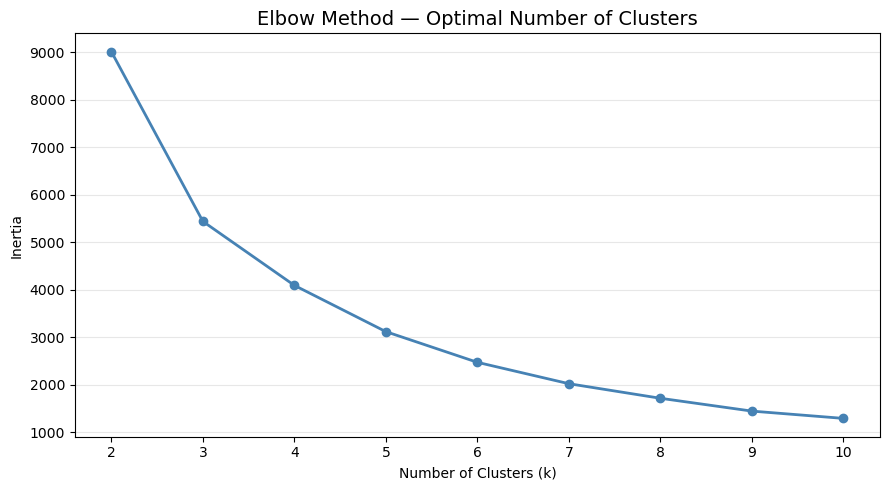

In [25]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3 - Silhouette Score (confirm the elbow)

The Silhouette Score measures how well each customer fits its assigned cluster
vs neighbouring clusters. Score ranges from -1 to 1 — higher is better.
We use this to confirm the k chosen from the elbow plot.

k=2  →  Silhouette Score: 0.8958
k=3  →  Silhouette Score: 0.5942
k=4  →  Silhouette Score: 0.6162
k=5  →  Silhouette Score: 0.6165
k=6  →  Silhouette Score: 0.5963
k=7  →  Silhouette Score: 0.5165
k=8  →  Silhouette Score: 0.4859
k=9  →  Silhouette Score: 0.4777
k=10  →  Silhouette Score: 0.4214


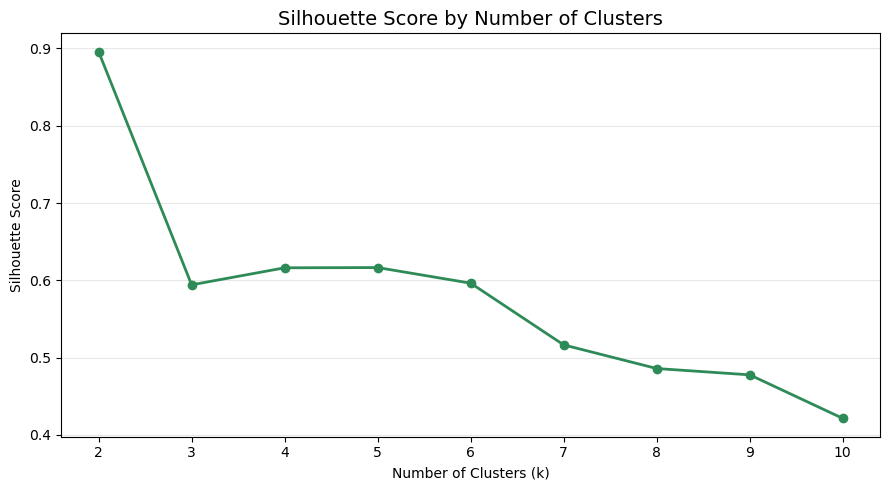

In [26]:
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled_df)
    score = silhouette_score(rfm_scaled_df, labels)
    silhouette_scores.append(score)
    print(f"k={k}  →  Silhouette Score: {score:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='seagreen', linewidth=2)
plt.title('Silhouette Score by Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 - Fit Final K-Means Model

Based on the elbow plot and silhouette scores, we select the optimal k.
(Typically k=3 or k=4 for RFM data — use whichever your plots suggest.)

In [27]:
# Set k based on your elbow/silhouette plots — usually 3 or 4
OPTIMAL_K = 4

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm_df['Cluster'] = km_final.fit_predict(rfm_scaled_df)

print(f"Cluster distribution:")
print(rfm_df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


## Step 5 - Cluster Profiling

Now we look at the average Recency, Frequency, and Monetary value for each
cluster to understand what type of customer each cluster represents.

In [28]:
cluster_profile = rfm_df.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


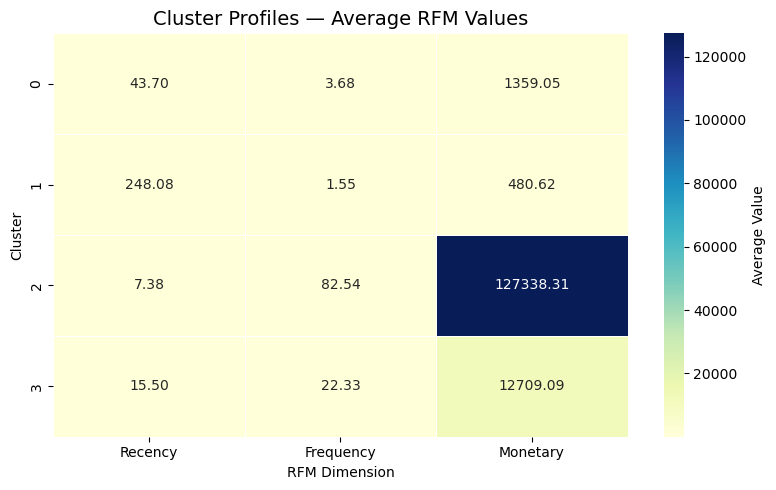

In [29]:
#heatmap of cluster profiles
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Average Value'})
plt.title('Cluster Profiles — Average RFM Values', fontsize=14)
plt.xlabel('RFM Dimension')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

## Step 6 - Label Clusters

After profiling, assign a human-readable label to each cluster based on
its RFM characteristics. Adjust these labels based on what your own
cluster profile output shows.

In [30]:
cluster_labels = {
    0: 'Loyal Customers',      # Low recency, high frequency, high monetary
    1: 'Lost',         # High recency, moderate frequency
    2: 'Champions',  # High recency, low frequency, low monetary
    3: 'High Value'        # Low recency, low frequency, growing monetary
}

rfm_df['Cluster_Label'] = rfm_df['Cluster'].map(cluster_labels)
print(rfm_df['Cluster_Label'].value_counts())

Cluster_Label
Loyal Customers    3054
Lost               1067
High Value          204
Champions            13
Name: count, dtype: int64


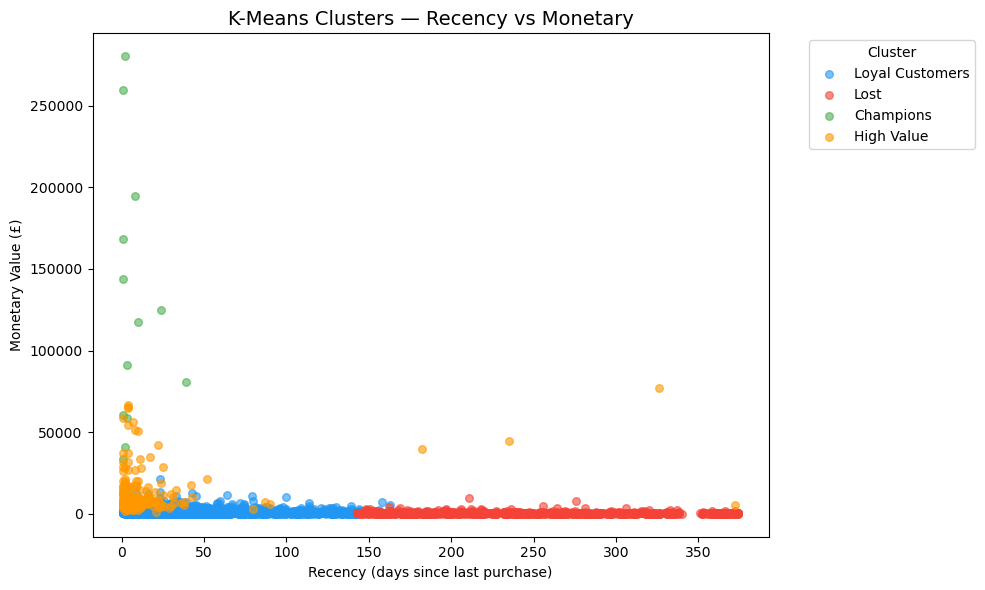

In [31]:
#scatter plot of clusters
plt.figure(figsize=(10, 6))

colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for cluster_id in sorted(rfm_df['Cluster'].unique()):
    subset = rfm_df[rfm_df['Cluster'] == cluster_id]
    label = cluster_labels[cluster_id]
    plt.scatter(subset['Recency'], subset['Monetary'],
                label=label, alpha=0.6, s=30,
                color=colors[cluster_id])

plt.title('K-Means Clusters — Recency vs Monetary', fontsize=14)
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value (£)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Step 7 - Comparison with Rule-Based Segments

We compare K-Means clusters against the rule-based segments from notebook 2
to validate consistency. If both approaches largely agree, it strengthens
confidence in the segmentation.

Cluster_Label    Champions  High Value  Lost  Loyal Customers
Segment                                                      
At Risk                  0           6   291              346
Champions               11         191     0              937
Lost                     0           1   776              288
Loyal Customers          2           6     0              813
Needs Attention          0           0     0              351
Promising                0           0     0              319


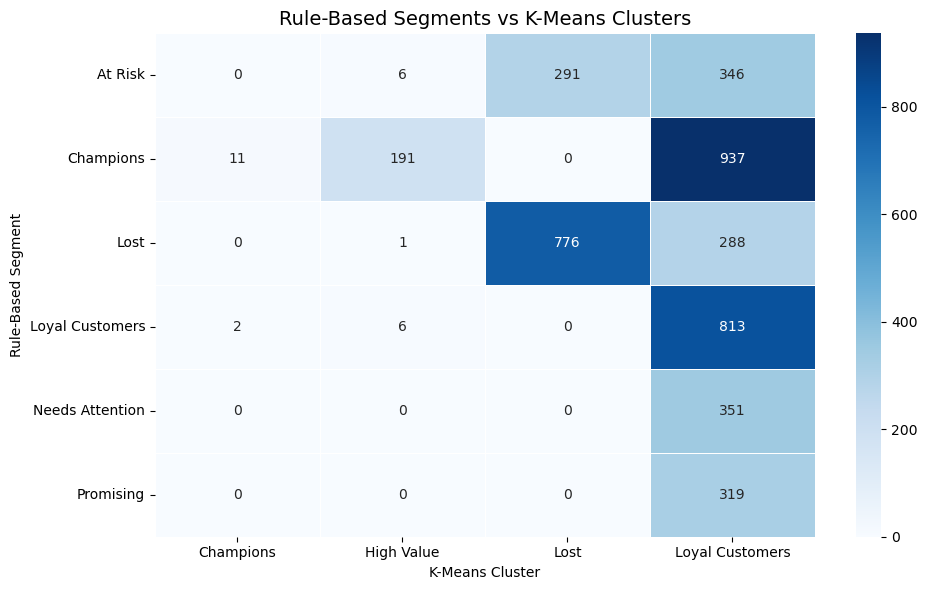

In [32]:
comparison = pd.crosstab(rfm_df['Segment'], rfm_df['Cluster_Label'])
print(comparison)

plt.figure(figsize=(10, 6))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Rule-Based Segments vs K-Means Clusters', fontsize=14)
plt.xlabel('K-Means Cluster')
plt.ylabel('Rule-Based Segment')
plt.tight_layout()
plt.show()

## Key Insights

K-Means clustering on RFM features produces groupings that broadly align with
the rule-based segments, validating our manual segmentation approach. However,
K-Means reveals natural groupings in the data without any predefined thresholds
— making it a more objective and scalable segmentation method.

The cluster profiles and the rule-based segments can be used together:
- **K-Means** for discovering segments in new or unseen data
- **Rule-based** for explainability to non-technical stakeholders

In [33]:
rfm_df.to_csv("../data/rfm_clustered.csv", index=False)
print("Saved rfm_clustered.csv")

Saved rfm_clustered.csv
